In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [26]:
# Built-in
import os
import json
import datetime

# PlatoSim standard
import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy import constants as c
from pathlib import Path

# PlatoSim libraries
import platosim.smbhb as smbhb
import platosim.utilities as ut
from platosim.lightcurve import LightCurve
from platosim.matplotlibrc import setup_paper
setup_paper()

from IPython.display import display, HTML
display(HTML("<style>.container {width:70% !important; }</style>"))

In [5]:
# Paths to where data is stored
path = Path(os.getenv('PLATO_WORKDIR')) / 'smbhb'
fdir = path / 'figures'
sdir = path / 'simulations/lcs'
rdir = sdir / 'reduced'
vdir = sdir / 'varsource'
udir = path / 'results'

In [95]:
def plot_quarter_marks(ax, time, N):
    quarter = ut.quarter()
    n_quarter = int(np.ceil(time.iloc[-1] / quarter))
    quarters = []
    position = []
    for q in range(1, n_quarter+1):
        time_Q = q * quarter
        xpos = time_Q - quarter / 2
        quarters.append(q)
        position.append(xpos)
        for i in range(N):
            ax[i].axvline(x=time_Q, c='k', linestyle='--', lw=0.5, alpha=0.5, zorder=0)
    # Plot marks on top y-axis
    ax0 = ax[0].twiny()
    ax0.set_xticks(position)
    ax0.tick_params(axis='x', which='major', labelsize=15)
    ax0.set_xticklabels([f'Q{q}' for q in quarters])
    tmin = (min(quarters) - 1) * quarter
    tmax = (max(quarters)    ) * quarter
    ax0.set_xlim(tmin, tmax)

## Magnitude

In [44]:
# Load light curves of 1h cadence
dh1 = pd.read_feather(rdir / 'lc_spikey_mag160_1h.ftr')
dh2 = pd.read_feather(rdir / 'lc_spikey_mag170_1h.ftr')
dh3 = pd.read_feather(rdir / 'lc_spikey_mag180_1h.ftr')
dh4 = pd.read_feather(rdir / 'lc_spikey_mag190_1h.ftr')
dh_all = [dh1, dh2, dh3, dh4]

In [45]:
# Load light curves of 1d cadence
dd1 = pd.read_feather(rdir / 'lc_spikey_mag160_1d.ftr')
dd2 = pd.read_feather(rdir / 'lc_spikey_mag170_1d.ftr')
dd3 = pd.read_feather(rdir / 'lc_spikey_mag180_1d.ftr')
dd4 = pd.read_feather(rdir / 'lc_spikey_mag190_1d.ftr')
dd_all = [dd1, dd2, dd3, dd4]

In [53]:
# Single time array
th = dh1.time
td = dd1.time
N = len(dh_all)

In [47]:
# Load variable source injected
dv = pd.read_feather(vdir / 'varsource_spikey_fiducial_components.ftr')
dv.time /= 86400
dv.flux = (dv.flux - 1) * 1e3

<IPython.core.display.Javascript object>


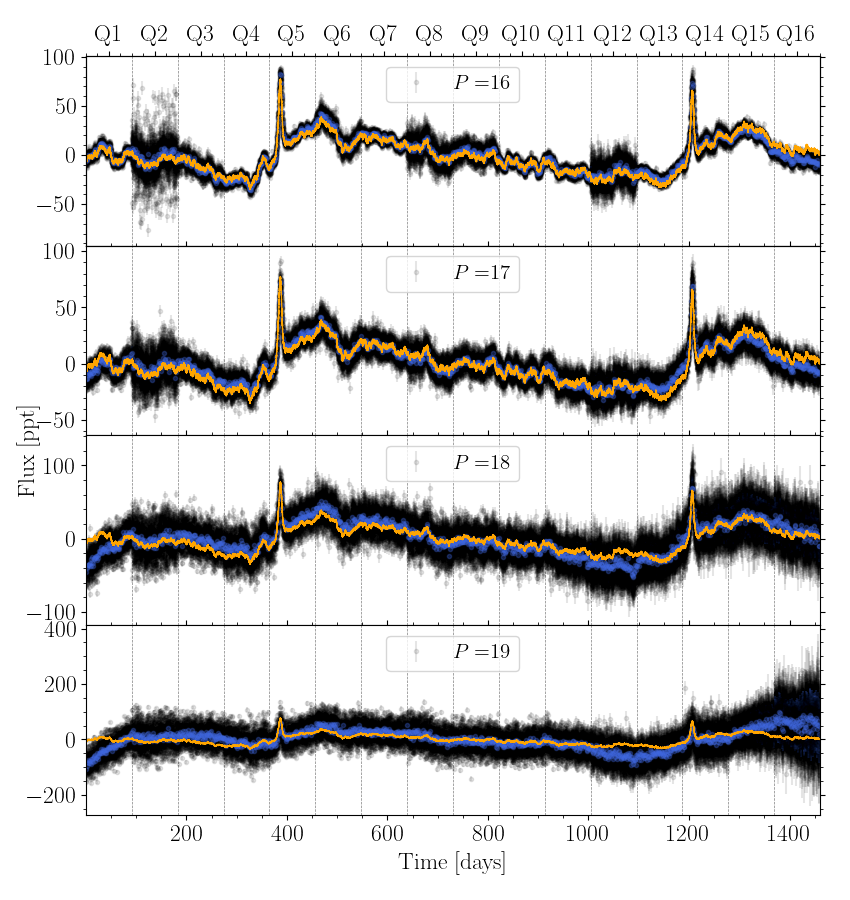

In [64]:
# Plot magnitude dependence of Spikey
fig, ax = plt.subplots(4, 1, figsize=(8.5, 9))
ah, ad = 0.1, 0.3
ch, cd = 'k', 'royalblue'

for i, dh, dd in zip(range(4), dh_all, dd_all):
    fh, fh_err = (dh.flux - 1) * 1e3, dh.flux_err * 1e3
    fd, fd_err = (dd.flux - 1) * 1e3, dd.flux_err * 1e3
    ax[i].errorbar(th, fh, yerr=fh_err, fmt='.', c=ch, alpha=ah, zorder=1, label=rf'$P = ${16+i:.0f}')
    ax[i].errorbar(td, fd, yerr=fd_err, fmt='.', c=cd, alpha=ad, zorder=1)
    # # ax[0].plot(time, df_mag16.fmed, '-', c='royalblue', lw=0.5)
    ax[i].plot(dv.time, dv.flux, '-', c='orange', lw=1)
    # Settings
    ax[i].set_xlim(th.min(), th.max())
    ax[i].legend(loc='upper center', fontsize=15)
    
# Add quarter marks
plot_quarter_marks(ax, th, N)

# Global settings
ax[N-1].set_xlabel('Time [days]')
fig.text(0.02, 0.5, 'Flux [ppt]', va='center', rotation='vertical')
plt.tight_layout(h_pad=0)
fig.subplots_adjust(hspace=0)

# Save figure
# fig.savefig(fdir / 'lcs_mag.png', bbox_inches='tight', dpi=200)

## Parameter: $\omega$

In [102]:
# Load light curves of 1h cadence
dh1 = pd.read_feather(rdir / 'lc_spikey_w000_1h.ftr')
dh2 = pd.read_feather(rdir / 'lc_spikey_fiducial_1h.ftr')
dh3 = pd.read_feather(rdir / 'lc_spikey_w180_1h.ftr')
dh4 = pd.read_feather(rdir / 'lc_spikey_w270_1h.ftr')
dh_all = [dh1, dh2, dh3, dh4]

In [103]:
# Load light curves of 1d cadence
dd1 = pd.read_feather(rdir / 'lc_spikey_w000_1d.ftr')
dd2 = pd.read_feather(rdir / 'lc_spikey_fiducial_1d.ftr')
dd3 = pd.read_feather(rdir / 'lc_spikey_w180_1d.ftr')
dd4 = pd.read_feather(rdir / 'lc_spikey_w270_1d.ftr')
dd_all = [dd1, dd2, dd3, dd4]

In [104]:
# Load variable source injected
dv1 = pd.read_feather(vdir / 'varsource_spikey_w000_components.ftr')
dv2 = pd.read_feather(vdir / 'varsource_spikey_fiducial_components.ftr')
dv3 = pd.read_feather(vdir / 'varsource_spikey_w180_components.ftr')
dv4 = pd.read_feather(vdir / 'varsource_spikey_w270_components.ftr')
dv_all = [dv1, dv2, dv3, dv4]

In [118]:
# Plot variables
th = dh1.time
td = dd1.time
N = len(dh_all)
ah, ad = 0.1, 0.3
ch, cd, cv, cvm = 'k', 'gray', 'royalblue', 'orange'
omega = [0, 90, 180, 270]

<IPython.core.display.Javascript object>


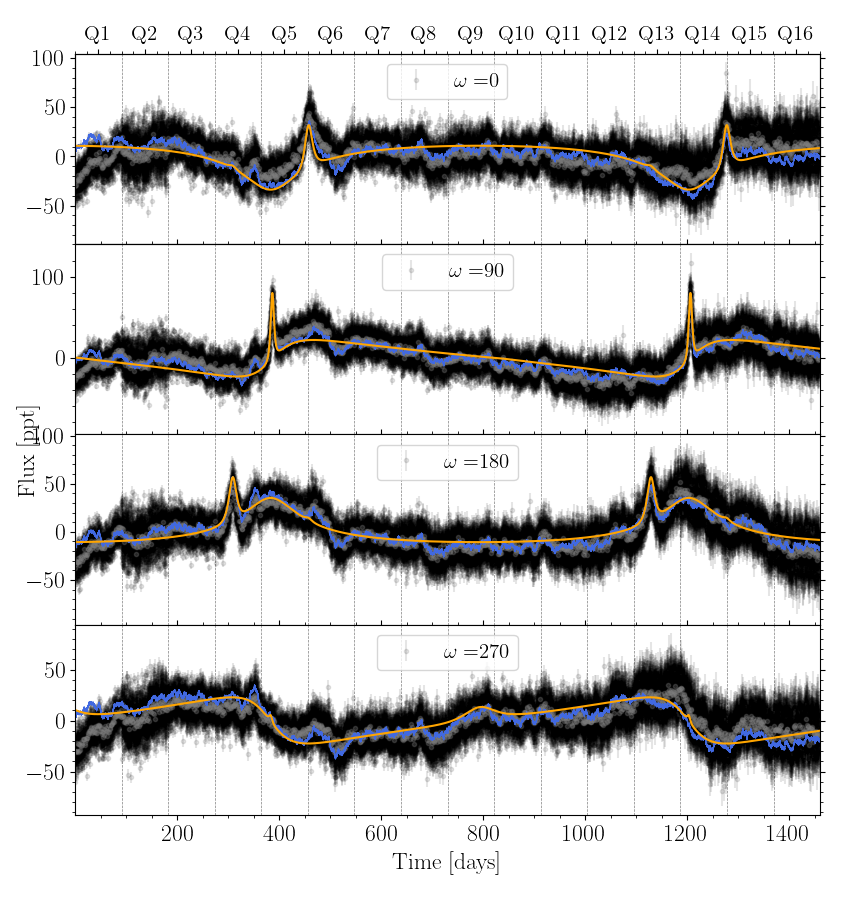

In [119]:
# Plot magnitude dependence of Spikey
fig, ax = plt.subplots(N, 1, figsize=(8.5, 9))

for i, x, dh, dd, dv in zip(range(N), omega, dh_all, dd_all, dv_all):
    # Get proper models
    fh, fh_err = (dh.flux - 1) * 1e3, dh.flux_err * 1e3
    fd, fd_err = (dd.flux - 1) * 1e3, dd.flux_err * 1e3
    tv, fv = dv.time / 86400, (dv.flux - 1) * 1e3
    fv_model = (dv.flux_boost * dv.flux_lens - 1) * 1e3 #- 70
    # Plot all
    ax[i].errorbar(th, fh, yerr=fh_err, fmt='.', c=ch, alpha=ah, zorder=1, label=rf'$\omega = ${x:.0f}')
    ax[i].errorbar(td, fd, yerr=fd_err, fmt='.', c=cd, alpha=ad, zorder=1)
    # # ax[0].plot(time, df_mag16.fmed, '-', c='royalblue', lw=0.5)
    ax[i].plot(tv, fv, '-', c=cv, lw=0.8)
    ax[i].plot(tv, fv_model, '-', c=cvm, lw=1.5)

    # Settings
    ax[i].set_xlim(th.min(), th.max())
    ax[i].legend(loc='upper center', fontsize=15)
    
# Add quarter marks
plot_quarter_marks(ax, th, N)

# Global settings
ax[N-1].set_xlabel('Time [days]')
fig.text(0.02, 0.5, 'Flux [ppt]', va='center', rotation='vertical')
plt.tight_layout(h_pad=0)
fig.subplots_adjust(hspace=0)

# Save figure
# fig.savefig(fdir / 'lcs_SFinf_tau30.png', bbox_inches='tight', dpi=200)

## Parameter:  $\text{SF}_\infty$ ($\tau = 10$ days)

In [127]:
# Load light curves of 1h cadence
dh1 = pd.read_feather(rdir / 'lc_spikey_tau10_sigma10_1h.ftr')
dh2 = pd.read_feather(rdir / 'lc_spikey_tau10_sigma20_1h.ftr')
dh3 = pd.read_feather(rdir / 'lc_spikey_tau10_sigma30_1h.ftr')
dh_all = [dh1, dh2, dh3]

In [128]:
# Load light curves of 1d cadence
dd1 = pd.read_feather(rdir / 'lc_spikey_tau10_sigma10_1d.ftr')
dd2 = pd.read_feather(rdir / 'lc_spikey_tau10_sigma20_1d.ftr')
dd3 = pd.read_feather(rdir / 'lc_spikey_tau10_sigma30_1d.ftr')
dd_all = [dd1, dd2, dd3]

In [129]:
# Load variable source injected
dv1 = pd.read_feather(vdir / 'varsource_spikey_tau10_sigma10_components.ftr')
dv2 = pd.read_feather(vdir / 'varsource_spikey_tau10_sigma20_components.ftr')
dv3 = pd.read_feather(vdir / 'varsource_spikey_tau10_sigma30_components.ftr')
dv_all = [dv1, dv2, dv3]

In [ ]:
# Plot variables
th = dh1.time
td = dd1.time
N = len(dh_all)
ah, ad = 0.1, 0.3
ch, cd, cv, cvm = 'k', 'gray', 'royalblue', 'orange'
params = [10, 20, 30]

<IPython.core.display.Javascript object>


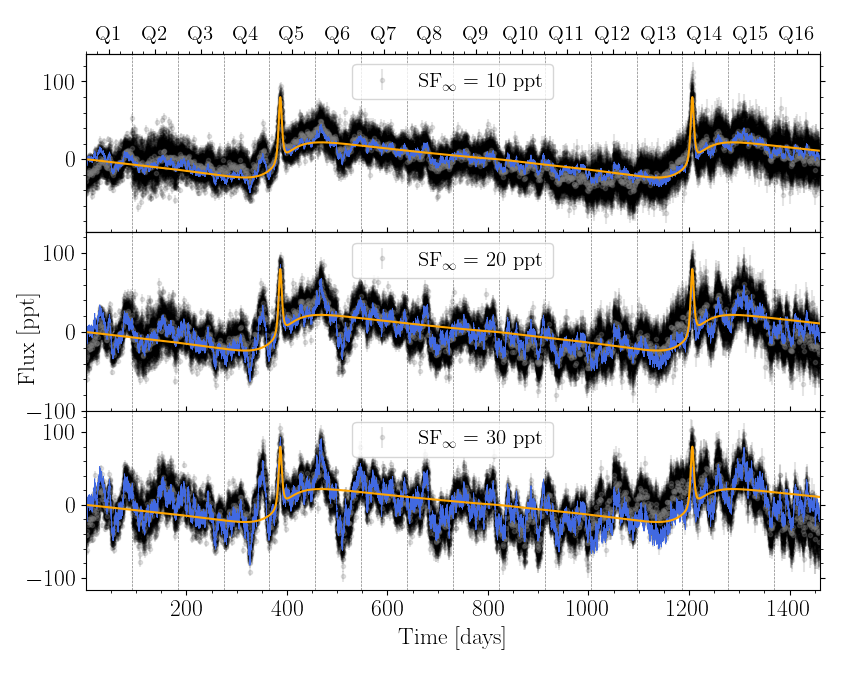

In [130]:
# Plot magnitude dependence of Spikey
fig, ax = plt.subplots(N, 1, figsize=(8.5, 2.25*N))
for i, x, dh, dd, dv in zip(range(N), params, dh_all, dd_all, dv_all):
    # Prepare plots
    fh, fh_err = (dh.flux - 1) * 1e3, dh.flux_err * 1e3
    fd, fd_err = (dd.flux - 1) * 1e3, dd.flux_err * 1e3
    tv, fv = dv.time / 86400, (dv.flux - 1) * 1e3
    fv_model = (dv.flux_boost * dv.flux_lens - 1) * 1e3
    # Make all plots
    ax[i].errorbar(th, fh, yerr=fh_err, fmt='.', c=ch, alpha=ah, zorder=1, label=rf'SF$_\infty =$ {x:.0f} ppt')
    ax[i].errorbar(td, fd, yerr=fd_err, fmt='.', c=cd, alpha=ad, zorder=1)
    # # ax[0].plot(time, df_mag16.fmed, '-', c='royalblue', lw=0.5)
    ax[i].plot(tv, fv, '-', c=cv, lw=0.5)
    ax[i].plot(tv, fv_model, '-', c=cvm, lw=1.5)
    # Settings
    ax[i].set_xlim(th.min(), th.max())
    ax[i].legend(loc='upper center', fontsize=15)  
# Add quarter marks
plot_quarter_marks(ax, th, N)
# Global settings
ax[N-1].set_xlabel('Time [days]')
fig.text(0.02, 0.5, 'Flux [ppt]', va='center', rotation='vertical')
plt.tight_layout(h_pad=0)
fig.subplots_adjust(hspace=0)
# Save figure
# fig.savefig(fdir / 'lcs_mag.png', bbox_inches='tight', dpi=200)

## Parameter:  $\text{SF}_\infty$ ($\tau = 30$ days)

In [120]:
# Load light curves of 1h cadence
dh1 = pd.read_feather(rdir / 'lc_spikey_tau30_sigma10_1h.ftr')
dh2 = pd.read_feather(rdir / 'lc_spikey_tau30_sigma20_1h.ftr')
dh3 = pd.read_feather(rdir / 'lc_spikey_tau30_sigma30_1h.ftr')
dh_all = [dh1, dh2, dh3]

In [121]:
# Load light curves of 1d cadence
dd1 = pd.read_feather(rdir / 'lc_spikey_tau30_sigma10_1d.ftr')
dd2 = pd.read_feather(rdir / 'lc_spikey_tau30_sigma20_1d.ftr')
dd3 = pd.read_feather(rdir / 'lc_spikey_tau30_sigma30_1d.ftr')
dd_all = [dd1, dd2, dd3]

In [122]:
# Load variable source injected
dv1 = pd.read_feather(vdir / 'varsource_spikey_tau30_sigma10_components.ftr')
dv2 = pd.read_feather(vdir / 'varsource_spikey_tau30_sigma20_components.ftr')
dv3 = pd.read_feather(vdir / 'varsource_spikey_tau30_sigma30_components.ftr')
dv_all = [dv1, dv2, dv3]

In [123]:
# Plot variables
th = dh1.time
td = dd1.time
N = len(dh_all)
ah, ad = 0.1, 0.3
ch, cd, cv, cvm = 'k', 'gray', 'royalblue', 'orange'
params = [10, 20, 30]

<IPython.core.display.Javascript object>


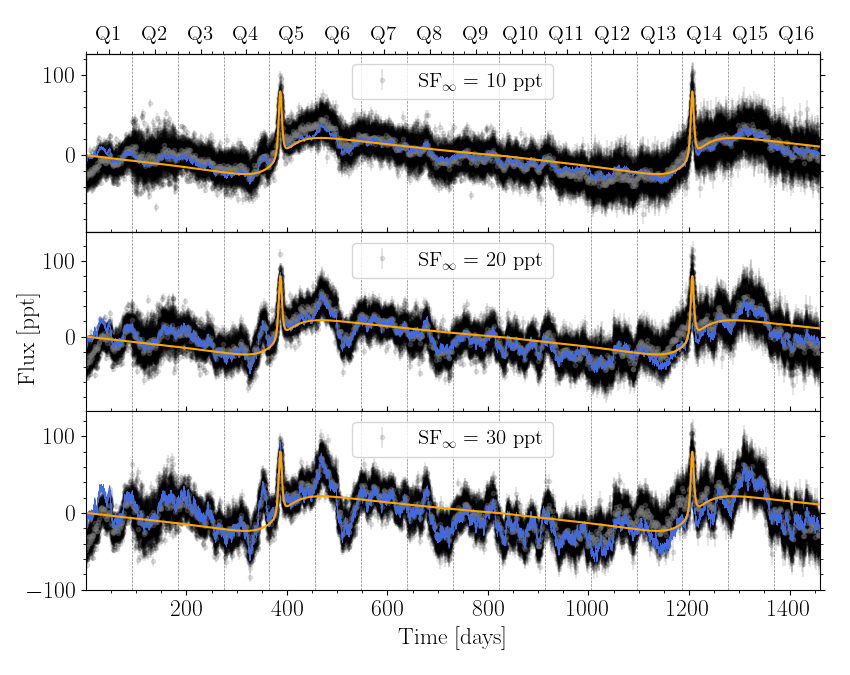

In [125]:
# Plot magnitude dependence of Spikey
fig, ax = plt.subplots(N, 1, figsize=(8.5, 2.25*N))
for i, x, dh, dd, dv in zip(range(N), params, dh_all, dd_all, dv_all):
    # Prepare plots
    fh, fh_err = (dh.flux - 1) * 1e3, dh.flux_err * 1e3
    fd, fd_err = (dd.flux - 1) * 1e3, dd.flux_err * 1e3
    tv, fv = dv.time / 86400, (dv.flux - 1) * 1e3
    fv_model = (dv.flux_boost * dv.flux_lens - 1) * 1e3
    # Make all plots
    ax[i].errorbar(th, fh, yerr=fh_err, fmt='.', c=ch, alpha=ah, zorder=1, label=rf'SF$_\infty =$ {x:.0f} ppt')
    ax[i].errorbar(td, fd, yerr=fd_err, fmt='.', c=cd, alpha=ad, zorder=1)
    # # ax[0].plot(time, df_mag16.fmed, '-', c='royalblue', lw=0.5)
    ax[i].plot(tv, fv, '-', c=cv, lw=0.5)
    ax[i].plot(tv, fv_model, '-', c=cvm, lw=1.5)
    # Settings
    ax[i].set_xlim(th.min(), th.max())
    ax[i].legend(loc='upper center', fontsize=15)  
# Add quarter marks
plot_quarter_marks(ax, th, N)
# Global settings
ax[N-1].set_xlabel('Time [days]')
fig.text(0.02, 0.5, 'Flux [ppt]', va='center', rotation='vertical')
plt.tight_layout(h_pad=0)
fig.subplots_adjust(hspace=0)
# Save figure
# fig.savefig(fdir / 'lcs_mag.png', bbox_inches='tight', dpi=200)

## Parameter:  $\text{SF}_\infty$ ($\tau = 50$ days)

In [131]:
# Load light curves of 1h cadence
dh1 = pd.read_feather(rdir / 'lc_spikey_tau50_sigma10_1h.ftr')
dh2 = pd.read_feather(rdir / 'lc_spikey_tau50_sigma20_1h.ftr')
dh3 = pd.read_feather(rdir / 'lc_spikey_tau50_sigma30_1h.ftr')
dh_all = [dh1, dh2, dh3]

In [132]:
# Load light curves of 1d cadence
dd1 = pd.read_feather(rdir / 'lc_spikey_tau50_sigma10_1d.ftr')
dd2 = pd.read_feather(rdir / 'lc_spikey_tau50_sigma20_1d.ftr')
dd3 = pd.read_feather(rdir / 'lc_spikey_tau50_sigma30_1d.ftr')
dd_all = [dd1, dd2, dd3]

In [133]:
# Load variable source injected
dv1 = pd.read_feather(vdir / 'varsource_spikey_tau50_sigma10_components.ftr')
dv2 = pd.read_feather(vdir / 'varsource_spikey_tau50_sigma20_components.ftr')
dv3 = pd.read_feather(vdir / 'varsource_spikey_tau50_sigma30_components.ftr')
dv_all = [dv1, dv2, dv3]

In [134]:
# Plot variables
th = dh1.time
td = dd1.time
N = len(dh_all)
ah, ad = 0.1, 0.3
ch, cd, cv, cvm = 'k', 'gray', 'royalblue', 'orange'
params = [10, 20, 30]

<IPython.core.display.Javascript object>


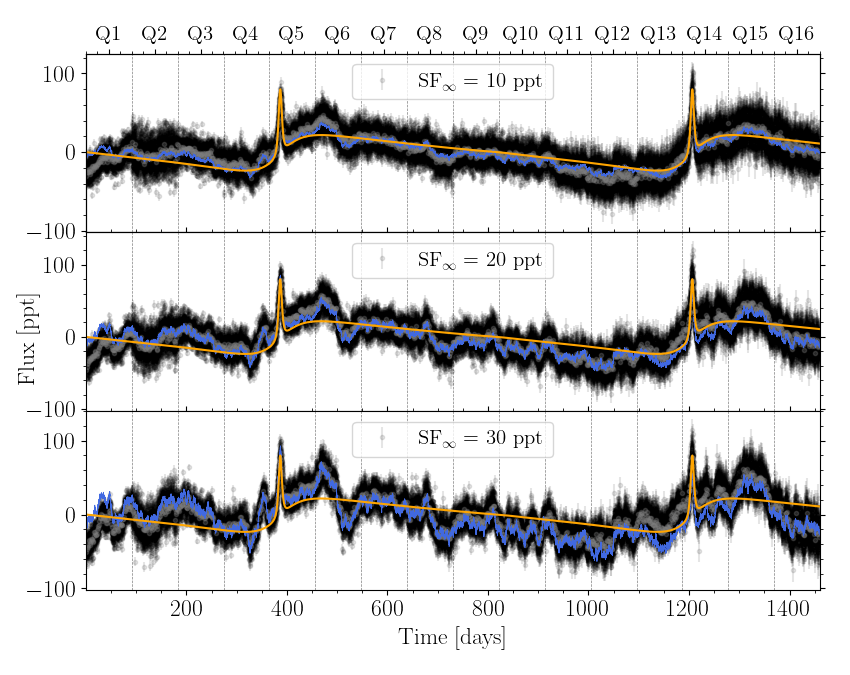

In [135]:
# Plot magnitude dependence of Spikey
fig, ax = plt.subplots(N, 1, figsize=(8.5, 2.25*N))
for i, x, dh, dd, dv in zip(range(N), params, dh_all, dd_all, dv_all):
    # Prepare plots
    fh, fh_err = (dh.flux - 1) * 1e3, dh.flux_err * 1e3
    fd, fd_err = (dd.flux - 1) * 1e3, dd.flux_err * 1e3
    tv, fv = dv.time / 86400, (dv.flux - 1) * 1e3
    fv_model = (dv.flux_boost * dv.flux_lens - 1) * 1e3
    # Make all plots
    ax[i].errorbar(th, fh, yerr=fh_err, fmt='.', c=ch, alpha=ah, zorder=1, label=rf'SF$_\infty =$ {x:.0f} ppt')
    ax[i].errorbar(td, fd, yerr=fd_err, fmt='.', c=cd, alpha=ad, zorder=1)
    # # ax[0].plot(time, df_mag16.fmed, '-', c='royalblue', lw=0.5)
    ax[i].plot(tv, fv, '-', c=cv, lw=0.5)
    ax[i].plot(tv, fv_model, '-', c=cvm, lw=1.5)
    # Settings
    ax[i].set_xlim(th.min(), th.max())
    ax[i].legend(loc='upper center', fontsize=15)  
# Add quarter marks
plot_quarter_marks(ax, th, N)
# Global settings
ax[N-1].set_xlabel('Time [days]')
fig.text(0.02, 0.5, 'Flux [ppt]', va='center', rotation='vertical')
plt.tight_layout(h_pad=0)
fig.subplots_adjust(hspace=0)
# Save figure
# fig.savefig(fdir / 'lcs_mag.png', bbox_inches='tight', dpi=200)